# House Price Predictor Model

## Objective: 
Build a House Price Prediciton Model For Houses in Karachi

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = 'Entities.csv'
df = pd.read_csv(path)
df.head()

,Unnamed: 0,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,purpose,bedrooms,date_added,agency,agent,Total_Area
0,0,237062,3325,https://www.zameen.com/Property/g_10_g_10_2_gr...,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,For Sale,2,2/4/2019,NaN,NaN,1089.004
1,1,346905,3236,https://www.zameen.com/Property/e_11_2_service...,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,For Sale,3,5/4/2019,NaN,NaN,15246.056
2,2,386513,764,https://www.zameen.com/Property/islamabad_g_15...,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,For Sale,5,7/17/2019,NaN,NaN,2178.008
3,3,656161,340,https://www.zameen.com/Property/islamabad_bani...,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,For Sale,4,4/5/2019,NaN,NaN,10890.000
4,4,841645,3226,https://www.zameen.com/Property/dha_valley_dha...,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,For Sale,3,7/10/2019,Easy Property,Muhammad Junaid Ceo Muhammad Shahid Director,2178.008


removing unwanted columns

In [3]:
df.columns

Index(['Unnamed: 0', 'property_id', 'location_id', 'page_url', 'property_type',
       'price', 'location', 'city', 'province_name', 'latitude', 'longitude',
       'baths', 'purpose', 'bedrooms', 'date_added', 'agency', 'agent',
       'Total_Area'],
      dtype='object')

In [4]:
cols_to_keep = ['property_type','purpose','baths','bedrooms','location','Total_Area','city','price','page_url']
df =  df[cols_to_keep]

In [5]:
cols_rename = {'Total_Area': 'sqft'}
df.rename(columns=cols_rename,inplace=True)

In [6]:
#subsetting for karachi
df = df[df['city']=='Karachi']

In [7]:
df.drop(columns=['city'],inplace=True)

In [8]:
df['price'] = df['price']/1e5

In [9]:
df['property_type'].unique()

array(['House', 'Flat', 'Room', 'Lower Portion', 'Upper Portion',
       'Penthouse', 'Farm House'], dtype=object)

In [10]:
# keeping the model genereic. removin penthhouse and farm house
property_to_rem = ['Penthouse','Farm House','Room']
bool_mask = df['property_type'].isin(property_to_rem)
df = df[~(bool_mask)]
df.property_type.unique()

array(['House', 'Flat', 'Lower Portion', 'Upper Portion'], dtype=object)

In [11]:
#imputing values for bathrooms and bedrooms where the value is 0 with its median value
bath_med = df['baths'].median()
bed_med = df['bedrooms'].median()

df.loc[df['baths'] == 0, 'baths'] = bath_med
df.loc[df['bedrooms'] == 0, 'bedrooms'] = bed_med

In [12]:
df[(df['baths'] == 0) | (df['bedrooms'] == 0)]

,property_type,purpose,baths,bedrooms,location,sqft,price,page_url


In [13]:
df.shape

(59960, 8)

In [14]:
mask = df['baths']>df['bedrooms']+2
df[mask].head()

,property_type,purpose,baths,bedrooms,location,sqft,price,page_url
1738,House,For Sale,7,4,Scheme 33,13068.048,115.0,https://www.zameen.com/Property/scheme_33_hadi...
2068,House,For Sale,9,6,Gulshan-e-Iqbal Town,98010.000,950.0,https://www.zameen.com/Property/gulshan_e_iqba...
2279,House,For Rent,8,5,Jamshed Town,4356.016,3.0,https://www.zameen.com/Property/pechs_pechs_bl...
3162,House,For Sale,7,4,Korangi,13068.048,160.0,https://www.zameen.com/Property/korangi_mbchs_...
3775,House,For Sale,10,6,Cantt,59895.000,950.0,https://www.zameen.com/Property/malir_cantonme...


In [15]:
bckp_df = df.copy(deep=True) # to keep backup

In [16]:
# removing unsual number of beds and bathrooms

mask1 = df['baths'] > df['bedrooms'] + 2  # Baths exceed bedrooms by more than 2
mask2 = df['baths'] < df['bedrooms'] / 2   # Baths are less than half the number of bedrooms

df = df[~(mask1 | mask2)]

AREA BASED ANAMOLY FILTERING

In [17]:
df['sqft'].describe()

count    5.924800e+04
mean     1.329492e+04
std      2.118058e+04
min      0.000000e+00
25%      3.267012e+03
50%      1.143454e+04
75%      1.579056e+04
max      3.267000e+06
Name: sqft, dtype: float64

In [18]:
df = df[~(df['sqft'] == 0)]

In [19]:
df['sqft'].describe()

count    5.924700e+04
mean     1.329514e+04
std      2.118068e+04
min      2.722510e+02
25%      3.267012e+03
50%      1.143454e+04
75%      1.579056e+04
max      3.267000e+06
Name: sqft, dtype: float64

In [20]:
mask = df['sqft'] == df['sqft'].quantile(0.75)
df[mask].head()

,property_type,purpose,baths,bedrooms,location,sqft,price,page_url
540,Flat,For Sale,2,2,Fazaia Housing Scheme,15790.558,46.66,https://www.zameen.com/Property/karachi_fazaia...
728,Flat,For Sale,2,2,Fazaia Housing Scheme,15790.558,46.66,https://www.zameen.com/Property/karachi_fazaia...
849,Flat,For Sale,2,2,Fazaia Housing Scheme,15790.558,46.66,https://www.zameen.com/Property/karachi_fazaia...
857,Flat,For Sale,2,2,Fazaia Housing Scheme,15790.558,46.66,https://www.zameen.com/Property/karachi_fazaia...
1015,Flat,For Sale,2,2,Fazaia Housing Scheme,15790.558,46.66,https://www.zameen.com/Property/karachi_fazaia...


In [21]:
x = df.loc[540]
print(x)
x['sqft']/(x['bedrooms'])

property_type                                                 Flat
purpose                                                   For Sale
baths                                                            2
bedrooms                                                         2
location                                     Fazaia Housing Scheme
sqft                                                     15790.558
price                                                        46.66
page_url         https://www.zameen.com/Property/karachi_fazaia...
Name: 540, dtype: object


7895.279

having 15000 sqft is unusual for 2 baths bed and 3bath and bed. It is an anamoly

In [22]:
bckp_df = df.copy(deep=True) # to keep backup

In [23]:
df.shape

(59247, 8)

In [24]:
df[df['sqft']>10000]

,property_type,purpose,baths,bedrooms,location,sqft,price,page_url
156,House,For Sale,7,6,Cantt,21780.000,4500.0,https://www.zameen.com/Property/faisal_cantonm...
158,Flat,For Sale,3,3,DHA Defence,24230.339,210.0,https://www.zameen.com/Property/d_h_a_dha_phas...
160,House,For Sale,4,4,Gadap Town,26136.096,130.0,https://www.zameen.com/Property/surjani_town_s...
163,Flat,For Sale,4,4,Gulshan-e-Iqbal Town,26680.598,165.0,https://www.zameen.com/Property/gulshan_e_iqba...
165,House,For Sale,6,5,Scheme 33,26136.096,128.0,https://www.zameen.com/Property/scheme_33_saad...
...,...,...,...,...,...,...,...,...
168440,Flat,For Sale,3,2,Gadap Town,10345.538,48.0,https://www.zameen.com/Property/gulshan_e_maym...
168441,House,For Sale,3,6,Gadap Town,26136.096,265.0,https://www.zameen.com/Property/gulshan_e_maym...
168443,House,For Sale,3,6,Gadap Town,26136.096,270.0,https://www.zameen.com/Property/gulshan_e_maym...
168444,House,For Sale,3,3,Gadap Town,21235.578,110.0,https://www.zameen.com/Property/gulshan_e_maym...


area data is very inaccurate. In order to remedy this we will use the page url to scrap the correct area and convert it back to sqft

In [25]:
df.reset_index(drop=True,inplace=True)

In [26]:
# df.to_csv('output.csv', index=False, sep=',', encoding='utf-8')

In [2]:
ktown = pd.read_csv('corrected_areas.csv')

In [3]:
ktown.head()

,property_type,purpose,baths,bedrooms,location,sqft,price,page_url,area,val,unit,area_sqft
0,House,For Sale,7,6,Cantt,21780.000,4500.0,https://www.zameen.com/Property/faisal_cantonm...,"2,000 Sq. Yd.","2,000",Sq. Yd.,18000.0
1,House,For Sale,8,6,Gulistan-e-Jauhar,4356.016,350.0,https://www.zameen.com/Property/karachi_gulist...,400 Sq. Yd.,400,Sq. Yd.,3600.0
2,Flat,For Sale,3,3,DHA Defence,24230.339,210.0,https://www.zameen.com/Property/d_h_a_dha_phas...,222 Sq. Yd.,222,Sq. Yd.,1998.0
3,House,For Sale,1,2,Malir,8712.032,65.0,https://www.zameen.com/Property/malir_malir_ka...,106 Sq. Yd.,106,Sq. Yd.,954.0
4,House,For Sale,4,4,Gadap Town,26136.096,130.0,https://www.zameen.com/Property/surjani_town_s...,240 Sq. Yd.,240,Sq. Yd.,2160.0


In [4]:
ktown.columns

Index(['property_type', 'purpose', 'baths', 'bedrooms', 'location', 'sqft',
       'price', 'page_url', 'area', 'val', 'unit', 'area_sqft'],
      dtype='object')

In [5]:
cols_to_keep = ['property_type', 'purpose', 'baths', 'bedrooms', 'location', 'area_sqft',
       'price']

ktown = ktown[cols_to_keep]

<Axes: >

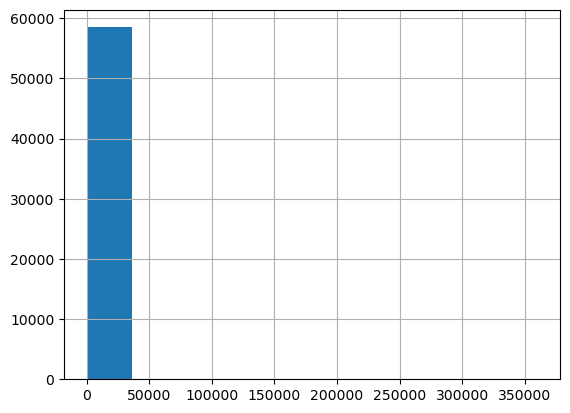

In [6]:
ktown['area_sqft'].hist()

In [7]:
ktown['area_sqft'].max()

360000.0

In [8]:
ktown['area_sqft'].describe()

count     58519.000000
mean       2021.419897
std        2905.928377
min          54.000000
25%         999.000000
50%        1404.000000
75%        2241.000000
max      360000.000000
Name: area_sqft, dtype: float64

In [9]:
#removing outlies using iqr method

q1 = ktown['area_sqft'].quantile(0.25)
q3 = ktown['area_sqft'].quantile(0.75)

iqr = q3-q1

lb = q1 - 1.5 * iqr #lower bound
ub = q3 + 1.5 * iqr #upper bound

lb , ub

(-864.0, 4104.0)

In [10]:
mask = (ktown['area_sqft']>=lb) & (ktown['area_sqft']<=ub)

ktown = ktown[mask]

In [11]:
ktown['area_sqft'].describe()

count    51882.000000
mean      1495.948729
std        752.342129
min         54.000000
25%        954.000000
50%       1251.000000
75%       1800.000000
max       4104.000000
Name: area_sqft, dtype: float64

In [12]:
# finding unsually very tight or impractical houses.

mask = ktown['area_sqft']/ktown['bedrooms']<300

ktown = ktown[~mask]

finding unsually spacious places

In [13]:
ktown[ktown['area_sqft']/ktown['bedrooms']>1000]

,property_type,purpose,baths,bedrooms,location,area_sqft,price
44,Flat,For Sale,3,2,DHA Defence,2052.0,350.00
45,Flat,For Sale,1,1,DHA Defence,1350.0,250.00
56,Lower Portion,For Rent,3,3,Gulshan-e-Iqbal Town,3600.0,1.50
57,Flat,For Sale,1,1,DHA Defence,1242.0,305.00
112,House,For Sale,4,3,Gulshan-e-Iqbal Town,3600.0,400.00
...,...,...,...,...,...,...,...
58356,House,For Sale,3,3,Bahria Town Karachi,3150.0,156.00
58366,House,For Sale,3,3,Bahria Town Karachi,3150.0,145.00
58417,Lower Portion,For Rent,4,4,Gulistan-e-Jauhar,4050.0,0.45
58443,Upper Portion,For Rent,3,3,Gulistan-e-Jauhar,4050.0,0.45


In [14]:
ktown[ktown['area_sqft']/ktown['bedrooms']>1000]['bedrooms'].mean()

2.720890410958904

the mean represent that the area/bed above 1000 is unusual and potentially an anomaly

In [15]:
mask = ktown['area_sqft']/ktown['bedrooms']>1000

ktown = ktown[~mask]

In [16]:
bckp_df = ktown.copy(deep=True)

filtering outliers regarding prices

dataset contain two sets of pricing: for sale and for rent. We need to find outliers based on purpose as well as the location

In [17]:
ktown['price_per_sqft'] = ktown['price']*1e5/ktown['area_sqft']

In [18]:
ktown['price'] = ktown['price'] * 1e5 
ktown_rent = ktown[ktown['purpose']=='For Rent'].copy(deep=True)  # rent
ktown_sale = ktown[ktown['purpose']=='For Sale'].copy(deep=True)  # sale

In [19]:
def remove_outliers_by_location(df):
    cleaned_data = []
    for location, group in df.groupby('location'):
        Q1 = group['price_per_sqft'].quantile(0.25)
        Q3 = group['price_per_sqft'].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        cleaned_group = group[(group['price_per_sqft'] >= lower_bound) & (group['price_per_sqft'] <= upper_bound)]
        cleaned_data.append(cleaned_group)
    
    return pd.concat(cleaned_data)

In [20]:
ktown_sale_cleaned = remove_outliers_by_location(ktown_sale)

In [21]:
ktown_rent_cleaned = remove_outliers_by_location(ktown_rent)

In [22]:
ktown_cleaned = pd.concat([ktown_sale_cleaned, ktown_rent_cleaned ], ignore_index=True)

In [23]:
ktown_cleaned.drop(columns=['price_per_sqft'],inplace=True)

In [24]:
ktown_cleaned['price'] = ktown_cleaned['price']/1e5

In [25]:
ktown_cleaned

,property_type,purpose,baths,bedrooms,location,area_sqft,price
0,House,For Sale,6,8,APP Employees Co-operative Housing Society,3600.0,390.00
1,House,For Sale,9,8,APP Employees Co-operative Housing Society,3600.0,390.00
2,Flat,For Sale,2,2,ASF Housing Scheme,846.0,30.56
3,Flat,For Sale,2,2,ASF Housing Scheme,1152.0,28.00
4,Flat,For Sale,3,3,ASF Tower,1575.0,85.00
...,...,...,...,...,...,...,...
41537,House,For Rent,5,5,Zamzama,3150.0,2.80
41538,House,For Rent,5,5,Zamzama,3150.0,3.25
41539,House,For Rent,4,4,Zamzama,3150.0,2.75
41540,House,For Rent,4,4,Zamzama,3150.0,2.40


## DATA PREPPING FOR TRAINING

In [26]:
ktown_prcsd= ktown_cleaned.copy(deep=True)

In [27]:
locations = ktown_cleaned['location'].unique()
prop_type = ktown_cleaned['property_type'].unique()
purpose = ktown_cleaned['purpose'].unique()

In [28]:
# l = len(ktown_cleaned['purpose'].unique())

# purpose_map = dict(zip(ktown_cleaned['purpose'].unique(),np.arange(l)))

# l = len(ktown_cleaned['property_type'].unique())
# property_type_map = dict(zip(ktown_cleaned['property_type'].unique(),np.arange(l)))

# print(purpose_map)
# print(property_type_map)

# ktown_cleaned['purpose'] = ktown_cleaned['purpose'].map(purpose_map)

# ktown_cleaned['property_type'].map(property_type_map)

In [29]:
ktown_prcsd.head(3)

,property_type,purpose,baths,bedrooms,location,area_sqft,price
0,House,For Sale,6,8,APP Employees Co-operative Housing Society,3600.0,390.00
1,House,For Sale,9,8,APP Employees Co-operative Housing Society,3600.0,390.00
2,Flat,For Sale,2,2,ASF Housing Scheme,846.0,30.56


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [65]:
X['property_type'].unique()

array(['House', 'Flat', 'Upper Portion', 'Lower Portion'], dtype=object)

In [88]:
# Define the target variable and features
y = ktown_prcsd['price']
X = ktown_prcsd.drop(columns=['price'])

# Define categorical and numerical columns
categorical_cols = ['property_type', 'purpose', 'location']
numerical_cols = ['baths', 'bedrooms', 'area_sqft']

# Scale numerical features
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# One-hot encode categorical features
encoder = OneHotEncoder(sparse_output=False)
encoded_cats = encoder.fit_transform(X[categorical_cols])

# Create a DataFrame for the encoded categorical features
encoded_cats_df = pd.DataFrame(encoded_cats, columns=encoder.get_feature_names_out(categorical_cols))

# Concatenate the numerical and encoded categorical DataFrames
X_processed = pd.concat([X[numerical_cols], encoded_cats_df], axis=1)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# Display the shapes of the training and testing sets
print(f'Training set shape: {X_train.shape}, {y_train.shape}')
print(f'Testing set shape: {X_test.shape}, {y_test.shape}')


Training set shape: (33233, 200), (33233,)
Testing set shape: (8309, 200), (8309,)


In [97]:
ba = ktown_prcsd.head(1)[['baths','bedrooms','area_sqft']]
ba

,baths,bedrooms,area_sqft
0,6,8,3600.0


In [119]:
y[0]

390.0

In [99]:
scaler.transform(np.array(ba))

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[3.17323675, 5.24721029, 2.96025455]])

In [89]:
X_processed.head()

,baths,bedrooms,area_sqft,property_type_Flat,property_type_House,property_type_Lower Portion,property_type_Upper Portion,purpose_For Rent,purpose_For Sale,location_APP Employees Co-operative Housing Society,...,location_Super Highway,location_Surti Muslim Co-Operative Housing Society,location_Tariq Road,location_Teacher Society,location_Teachers Society,location_Times Residency,location_Tipu Sultan Road,location_University Road,location_Zamzama,location_circular road
0,3.173237,5.247210,2.960255,0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,6.283434,5.247210,2.960255,0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.973693,-0.910261,-1.007199,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.973693,-0.910261,-0.566371,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.063039,0.115984,0.043009,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Model Selection

In [68]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [69]:
# Define the models and their hyperparameters
models = {
    'Linear Regression': LinearRegression(),
    'Lasso Regression': Lasso(),
    'Ridge Regression': Ridge(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor()
}

# Define the hyperparameters for each model
param_grid = {
    'Linear Regression': {},
    'Lasso Regression': {'alpha': [0.01, 0.1, 1, 10, 100]},
    'Ridge Regression': {'alpha': [0.01, 0.1, 1, 10, 100]},
    'Decision Tree': {'max_depth': [None, 5, 10, 15, 20], 'min_samples_split': [2, 5, 10]},
    'Random Forest': {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, 15], 'min_samples_split': [2, 5, 10]}
}

In [35]:
# # Initialize a dictionary to hold the best models
# best_models = {}

# # Loop through each model and perform GridSearchCV
# for model_name, model in models.items():
#     grid_search = GridSearchCV(estimator=model, param_grid=param_grid[model_name], 
#                                scoring=['r2','neg_mean_squared_error'],refit='r2', cv=5, n_jobs=-1, verbose=1)
#     grid_search.fit(X_train, y_train)
    
#     # Store the best model and its parameters
#     best_models[model_name] = {
#         'best_model': grid_search.best_estimator_,
#         'best_params': grid_search.best_params_,
#         'best_score': grid_search.best_score_
#     }

# # Output the best models and their parameters
# for model_name, details in best_models.items():
#     print(f"{model_name}:")
#     print(f"  Best Parameters: {details['best_params']}")
#     print(f"  Best Score: {details['best_score']}")


In [38]:
best_models = {
    "Linear Regression": {
        "Best Parameters": {},
        "Best Score": -4.299840000852746e+19
    },
    "Lasso Regression": {
        "Best Parameters": {'alpha': 0.01},
        "Best Score": 0.6817133978338602
    },
    "Ridge Regression": {
        "Best Parameters": {'alpha': 1},
        "Best Score": 0.6828938126728473
    },
    "Decision Tree": {
        "Best Parameters": {'max_depth': None, 'min_samples_split': 10},
        "Best Score": 0.9160457936334401
    },
    "Random Forest": {
        "Best Parameters": {'max_depth': 15, 'min_samples_split': 10, 'n_estimators': 50},
        "Best Score": 0.9138742812379153
    }
}


#### RESULTS

Linear Regression:<br>
&nbsp;&nbsp;&nbsp;Best Parameters: {}<br>
&nbsp;&nbsp;&nbsp;Best Score: -4.299840000852746e+19<br>
Lasso Regression:<br>
&nbsp;&nbsp;&nbsp;Best Parameters: {'alpha': 0.01}<br>
&nbsp;&nbsp;&nbsp;Best Score: 0.6817133978338602<br>
Ridge Regression:<br>
&nbsp;&nbsp;&nbsp;Best Parameters: {'alpha': 1}<br>
&nbsp;&nbsp;&nbsp;Best Score: 0.6828938126728473<br>
Decision Tree:<br>
&nbsp;&nbsp;&nbsp;Best Parameters: {'max_depth': None, 'min_samples_split': 10}<br>
&nbsp;&nbsp;&nbsp;Best Score: 0.9160457936334401<br>
Random Forest:<br>
&nbsp;&nbsp;&nbsp;Best Parameters: {'max_depth': 15, 'min_samples_split': 10, 'n_estimators': 50}<br>
&nbsp;&nbsp;&nbsp;Best Score: 0.9138742812379153<br>



<b>Selcting Random Forest due to it being less prone to overfitting and being a better generalization model<b>

In [70]:
param = best_models['Random Forest']['Best Parameters']

model = RandomForestRegressor(**param)

model

RandomForestRegressor(max_depth=15, min_samples_split=10, n_estimators=50)

In [71]:
model.fit(X_train,y_train)

RandomForestRegressor(max_depth=15, min_samples_split=10, n_estimators=50)

In [72]:
model.score(X_test,y_test)

0.9114433686653904

<b>The model has 91% R2

Export

In [45]:
import pickle
import json

In [73]:
pickle.dump(model, open("model/model.pkl", "wb"))

In [80]:
col = list(X_processed.columns.to_numpy())
columns_dict = {'columns':col}
columns_dict

{'columns': ['baths',
  'bedrooms',
  'area_sqft',
  'property_type_Flat',
  'property_type_House',
  'property_type_Lower Portion',
  'property_type_Upper Portion',
  'purpose_For Rent',
  'purpose_For Sale',
  'location_APP Employees Co-operative Housing Society',
  'location_ASF Housing Scheme',
  'location_ASF Tower',
  'location_Abdullah Haroon Road',
  'location_Abid Town',
  'location_Abul Hassan Isphani Road',
  'location_Ahsan Grand City',
  'location_Airport',
  'location_Aisha Manzil',
  'location_Al-Hilal Society',
  'location_Al-Jadeed Residency',
  'location_Al-Manzar Society',
  'location_Al-Safaa Garden',
  'location_Allama Iqbal Town',
  'location_Altaf Hussain Road',
  'location_Amil Colony',
  'location_Amir Khusro',
  'location_Anda Mor Road',
  'location_Azam Town',
  'location_BMCHS',
  'location_Bagh-e-Korangi',
  'location_Bahria Town Karachi',
  'location_Baldia Town',
  'location_Baloch Colony',
  'location_Bath Island',
  'location_Bilal Town',
  'location_Bi

In [103]:
# Convert the list of columns to JSON
columns_json = json.dumps(columns_dict)

# Output the JSON
print(columns_json)

{"columns": ["baths", "bedrooms", "area_sqft", "property_type_Flat", "property_type_House", "property_type_Lower Portion", "property_type_Upper Portion", "purpose_For Rent", "purpose_For Sale", "location_APP Employees Co-operative Housing Society", "location_ASF Housing Scheme", "location_ASF Tower", "location_Abdullah Haroon Road", "location_Abid Town", "location_Abul Hassan Isphani Road", "location_Ahsan Grand City", "location_Airport", "location_Aisha Manzil", "location_Al-Hilal Society", "location_Al-Jadeed Residency", "location_Al-Manzar Society", "location_Al-Safaa Garden", "location_Allama Iqbal Town", "location_Altaf Hussain Road", "location_Amil Colony", "location_Amir Khusro", "location_Anda Mor Road", "location_Azam Town", "location_BMCHS", "location_Bagh-e-Korangi", "location_Bahria Town Karachi", "location_Baldia Town", "location_Baloch Colony", "location_Bath Island", "location_Bilal Town", "location_Bin Qasim Town", "location_Blue Bell Residency", "location_Britto Road",

In [76]:
with open('model/columns.json', 'w') as json_file:
    json.dump(columns_dict, json_file)

In [87]:
locations = col[9:]
locations

['location_APP Employees Co-operative Housing Society',
 'location_ASF Housing Scheme',
 'location_ASF Tower',
 'location_Abdullah Haroon Road',
 'location_Abid Town',
 'location_Abul Hassan Isphani Road',
 'location_Ahsan Grand City',
 'location_Airport',
 'location_Aisha Manzil',
 'location_Al-Hilal Society',
 'location_Al-Jadeed Residency',
 'location_Al-Manzar Society',
 'location_Al-Safaa Garden',
 'location_Allama Iqbal Town',
 'location_Altaf Hussain Road',
 'location_Amil Colony',
 'location_Amir Khusro',
 'location_Anda Mor Road',
 'location_Azam Town',
 'location_BMCHS',
 'location_Bagh-e-Korangi',
 'location_Bahria Town Karachi',
 'location_Baldia Town',
 'location_Baloch Colony',
 'location_Bath Island',
 'location_Bilal Town',
 'location_Bin Qasim Town',
 'location_Blue Bell Residency',
 'location_Britto Road',
 'location_Cantt',
 'location_Catholic Colony',
 'location_Chapal Courtyard',
 'location_Chapal Skymark',
 'location_Chapal Uptown',
 'location_Civil Lines',
 'loca

In [90]:
with open('model/scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

In [101]:
array = np.array([
    3.17323675, 5.24721029, 2.96025455, 1., 0., 0.,
    0., 0., 1., 0., 0., 0.,
    0., 0., 0., 0., 0., 0.,
    0., 0., 0., 0., 0., 0.,
    0., 1., 0., 0., 0., 0.,
    0., 0., 0., 0., 0., 0.,
    0., 0., 0., 0., 0., 0.,
    0., 0., 0., 0., 0., 0.,
    0., 0., 0., 0., 0., 0.,
    0., 0., 0., 0., 0., 0.,
    0., 0., 0., 0., 0., 0.,
    0., 0., 0., 0., 0., 0.,
    0., 0., 0., 0., 0., 0.,
    0., 0., 0., 0., 0., 0.,
    0., 0., 0., 0., 0., 0.,
    0., 0., 0., 0., 0., 0.,
    0., 0., 0., 0., 0., 0.,
    0., 0., 0., 0., 0., 0.,
    0., 0., 0., 0., 0., 0.,
    0., 0., 0., 0., 0., 0.,
    0., 0., 0., 0., 0., 0.,
    0., 0., 0., 0., 0., 0.
])

array.shape

(132,)

In [ ]:
# array.reshape(-1, 1)

In [109]:
np.array(X_train.head(1)).shape

(1, 200)

In [113]:
len(col)

200

In [118]:
array.shape

(132,)